<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_5/Day_2%20/Daily_challenge/Daily_challenge_Breast_cancer_w.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge: Breast Cancer Prediction
===

**Your Task**

Exploratory Data Analysis:

- Use pandas to load the dataset and examine the first few rows.
- Check and handle the missing values.
- Drop any unnecessary column
- Create a Countplot to display diagnosis from magma

Data Preprocessing, Building Models and Evaluation :

- counts of unique rows in the ‘diagnosis’ column
- map categorical values to numerical values
- Splitting the data into train and test
- Implement logistic regression and print the accuracy.
- Implement K Nearest Neighbours and print the accuracy.
- Implement Random Forests and print the accuracy.
- Implement Support Vector Machines (SVM) and print the accuracy.
- Which is the best model ?

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



**Exploratory Data Analysis:**

In [ ]:
#Loading the dataset
df = pd.read_csv('breast_cancer_wis.csv')
print("First 5 rows of the dataset:")
print(df.head())

print("--Info--:")
print(df.info())

#Checking missing values
print("\nMissing values per column:")
print(df.isnull().sum())

#Dropping
df_clean = df.drop(columns=['id', 'Unnamed: 32'])



First 5 rows of the dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_

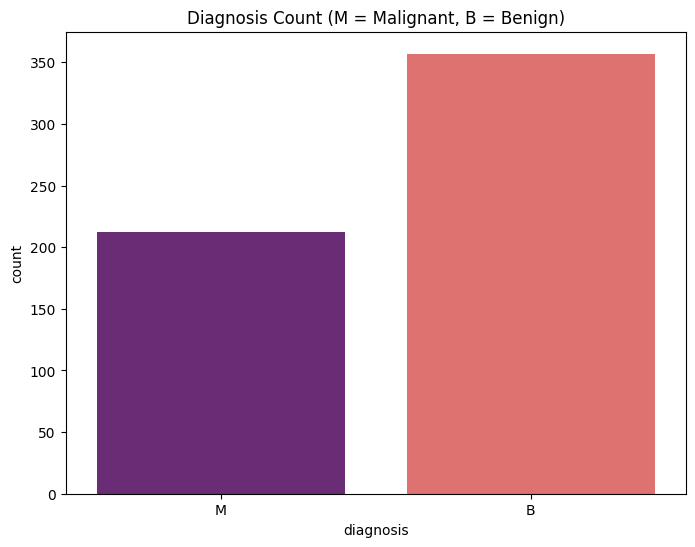

In [ ]:
#Countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='diagnosis', palette='magma', hue='diagnosis')
plt.title('Diagnosis Count (M = Malignant, B = Benign)')
plt.savefig('diagnosis_countplot.png')

**Data Preprocessing, Building Models and Evaluation :**

In [ ]:
diagnosis_counts = df_clean['diagnosis'].value_counts()
print("Diagnosis counts:")
print(diagnosis_counts)

df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})
print(df_clean[['diagnosis']].head())

Diagnosis counts:
diagnosis
B    357
M    212
Name: count, dtype: int64
   diagnosis
0          1
1          1
2          1
3          1
4          1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#Features and Target:
X = df_clean.drop('diagnosis', axis=1)
y = df_clean['diagnosis']

#Splitting into train and test:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling features:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Logistic regression:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr.predict(X_test_scaled)):.4f}")

#K Nearest Neighbours:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
print(f"KNN Accuracy: {accuracy_score(y_test, knn.predict(X_test_scaled)):.4f}")

#Random Forests:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.4f}")

#Support Vector Machines:
svm = SVC()
svm.fit(X_train_scaled, y_train)
print(f"SVM Accuracy: {accuracy_score(y_test, svm.predict(X_test_scaled)):.4f}")

Logistic Regression Accuracy: 0.9737
KNN Accuracy: 0.9474
Random Forest Accuracy: 0.9649
SVM Accuracy: 0.9825
